In [1]:
import math
import os
import time
import sys
sys.path.append(os.path.abspath('.')) # to run files that are away
os.environ["WANDB_SILENT"] = "true"  # Suppress WandB logs

libraries = ["torch", "numpy", "polars"]
modules   = {lib: sys.modules.get(lib) for lib in libraries}

if not modules["torch"]:
    import torch
if not modules["numpy"]:
    import numpy as np
if not modules["polars"]:
    import polars as pl

import pandas as pd
import gc
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from load_and_rename_files import LogFilesProcessor, WaferFilesProcessor
from prediction_methods import MultiOutputModelPredictor, DataPreprocessor
from asm_utils import count_missing_values_in_df, plot_all_columns_in_df, remove_constant_valued_cols, estimate_dataset_dimensionality

device     = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
def beep_sound(times=1, delay=0.2):
    for _ in range(times):
        os.system('afplay /System/Library/Sounds/Blow.aiff')
        time.sleep(delay)

import asm_data_wrangling as asm
from key_params import NUM_WAFERS, step_col_name, COMMON_ID_COLS, COMMON_ID_COLS_MOD, parquet_folder_name #, dict_of_wafer_files, dict_of_log_files 

log_processor = LogFilesProcessor(COMMON_ID_COLS_MOD, COMMON_ID_COLS)


In [2]:

# df = pl.read_csv(f'../ASM_data/2. marathon0/logs/Step1.csv', null_values=["", "NA", "null"], ignore_errors=True, separator=",")
pdf         = pd.read_csv(f'../ASM_data/2. marathon0/logs/Step1.csv', decimal='.')
pdf_numeric = pdf.select_dtypes(include='number') # removes strings
df          = pl.from_pandas(pdf_numeric)


3217
[0.         0.         0.         ... 0.00195312 0.00195312 0.00195312]


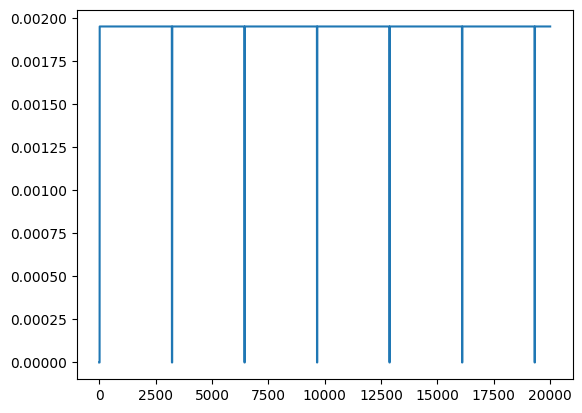

In [49]:
# plot_all_columns_in_df(pdf[pdf.columns[:10]])

df2 = remove_constant_valued_cols(df)
df_scaled = StandardScaler().fit_transform(df2)

num_rows_subsample = 500_000
if df_scaled.shape[0] > num_rows_subsample:
    idx = np.random.choice(df_scaled.shape[0], num_rows_subsample, replace=False)
    df_scaled_sample = df_scaled[idx]
else:
    df_scaled_sample = df_scaled

df_scaled = pl.DataFrame(df_scaled)  # Only do this if df_scaled is a NumPy array
# plot_all_columns_in_df(df_scaled.select(df_scaled.columns[:20]))
# plot_all_columns_in_df(df2.select(df2.columns[:20]))


# # plt.plot(df2[df2.columns[3]].to_numpy()[:200_000])
# y1 = df2[df2.columns[3]].to_numpy()[:5_0000]
# x1 = np.arange(len(y1))
# plt.scatter(x1, y1)#, s=1)  # s=1 for smaller points


def find_square_periodicity_of_feature(signal):
    """Requires a square function"""
    durations   = np.diff(np.where(np.diff(signal) != 0)[0])
    periods     = durations[::2] + durations[1::2]  # Sum long+short phases
    estimated_p = int(np.round(np.median(periods)))
    return estimated_p

def sin_encode(signal, periodicity):
    sin_encoded = np.sin(2 * np.pi * signal/periodicity)
    return sin_encoded

signal = df2[:, 3].to_numpy()
periodicity = find_square_periodicity_of_feature(signal)
sin_encoded = sin_encode(signal, periodicity)
print(periodicity)
print(sin_encoded)

plt.plot(sin_encoded[:20_000])

# p = 1
# sin_encoded = np.sin(2* np.pi* x/p)

# data_dimensionality = estimate_dataset_dimensionality(df_scaled_sample, 150)
# print(f"Recommended latent layer size: {data_dimensionality:.1f}")

# beep_sound(3, 0)

In [ ]:
import umap
reducer   = umap.UMAP()
embedding = reducer.fit_transform(df_scaled)
embedding.shape



KeyboardInterrupt: 

In [ ]:

main_folder   = "../ASM_data"
dict_of_wafer_files = {'file1': {'path': f"{main_folder}/2. marathon0/Wafer performance/Spatial property after step 4.csv", 'marathon': 0},
                       'file2': {'path': f"{main_folder}/3. marathon1/Wafer performance/Spatial property.csv", 'marathon': 1}}

dict_of_log_files = {'file1': {'path': f"{main_folder}/2. marathon0/logs/Step1.csv", 'step': 1, 'marathon': 0},
                     'file2': {'path': f"{main_folder}/2. marathon0/logs/Step2.csv", 'step': 2, 'marathon': 0},
                     'file3': {'path': f"{main_folder}/2. marathon0/logs/Step3.csv", 'step': 3, 'marathon': 0},
                     'file4': {'path': f"{main_folder}/2. marathon0/logs/Step4.csv", 'step': 4, 'marathon': 0},
                     'file5': {'path': f"{main_folder}/3. marathon1/logs/Step1.csv", 'step': 1, 'marathon': 1},
                     'file6': {'path': f"{main_folder}/3. marathon1/logs/Step2.csv", 'step': 2, 'marathon': 1},
                     'file7': {'path': f"{main_folder}/3. marathon1/logs/Step3.csv", 'step': 3, 'marathon': 1},
                     'file8': {'path': f"{main_folder}/3. marathon1/logs/Step4.csv", 'step': 4, 'marathon': 1},}

# def train_models(y_df_dict, radius_wide_dict, main_folder, num_wafers, device):
#     predictor    = MultiOutputModelPredictor(device)
#     preprocessor = DataPreprocessor()

#     marathon_run_col = "marathon_run"
#     wafer_col        = "wafer"

#     total_rmse_lgb, total_rmse_cat, total_rmse_rf, total_rmse_linreg, total_rmse_ridge = 0, 0, 0, 0, 0
#     for wafer_idx in range(num_wafers):
#         wafer_log_df             = pl.read_parquet(f"{main_folder}/{parquet_folder_name}/{wafer_col}_{wafer_idx+1}_log.parquet")
#         # processed_wafer_log_df   = _compute_log_df_grouped_stats(wafer_log_df, 'marathon_run')
#         processed_wafer_log_df   = asm._flatten_last_rows(wafer_log_df, marathon_run_col)
#         break
#     return processed_wafer_log_df

master_wafer_df, wafer_df_dict, y_df_dict, radius_wide_dict = asm.load_wafer_csv_and_create_targets(dict_of_wafer_files, main_folder, save=False)
unique_marathon_runs_list = list(master_wafer_df["marathon_run"].unique())
master_log_df = asm.load_process_and_combine_log_csv_files(dict_of_log_files, log_processor, unique_marathon_runs_list, step_col_name, main_folder, save=False)
master_log_df = remove_constant_valued_cols(master_log_df)
# asm.split_log_df_by_wafer_and_save_to_parquet(master_log_df, NUM_WAFERS, main_folder, log_processor, overwrite = False)
# processed_wafer_log_df = train_models(y_df_dict, radius_wide_dict, main_folder, NUM_WAFERS, device)



In [ ]:
df1 = pd.read_csv(f"{main_folder}/2. marathon0/logs/Step4.csv")
df2 = pd.read_csv(f"{main_folder}/3. marathon1/logs/Step4.csv")

print(df1.shape)
print(df2.shape)


(728932, 120)
(756555, 197)


In [ ]:
def read_csv_and_lowercase_cols_names(file_path: str) -> pl.DataFrame:
    """Read CSV into Polars DataFrame and title-case column names after stripping spaces"""
    df = pl.read_csv(file_path, ignore_errors=True)
    df = df.rename({c: c.strip().title() for c in df.columns})
    return df

count_missing_values_in_df(dict_of_log_files[1])


In [ ]:
y_pred_cat.shape
y_pred_unscaled = y_scaler.inverse_transform(y_pred_cat)

type(y_pred_cat)

NameError: name 'y_pred_cat' is not defined

In [ ]:
y_pred_unscaled = y_scaler.inverse_transform(y_pred_cat)

plt.scatter(range(len(y_full_pd.iloc[1].values)), y_full_pd.iloc[1].values,
            label="True", facecolors='none', edgecolors='blue', s=8)
plt.scatter(range(len(y_pred_unscaled[1])), y_pred_unscaled[1],
            label="Predicted", facecolors='none', edgecolors='orange', s=8)
# plt.plot(y_full_pd.iloc[1].values, label="True")
# plt.plot(y_pred_unscaled[1], label="Predicted")
plt.legend()
plt.title("y_predicted vs y_actual")
plt.xlabel("Site ID (coordinate)")
plt.ylabel("Spatial property")
plt.show()


In [ ]:
# hyperparam search

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'estimator__num_leaves': [20, 31, 40, 50],
    'estimator__max_depth': [-1, 5, 10, 20],
    'estimator__min_data_in_leaf': [10, 20, 30],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 500, 1000]}

# model = MultiOutputRegressor(xgb.XGBRegressor(objective='reg:squarederror', verbosity=0))
model = MultiOutputRegressor(LGBMRegressor(objective='regression', verbosity=-1))

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", (-search.best_score_)**0.5)



##### Spatial data (M)

In [ ]:
def plot_wafer_property(df, property_col, title):
    plt.figure(figsize=(9, 5))
    for rc_value, group in df.group_by("RC"):
        x = group["#Run"].to_list()
        y = group[property_col].to_list()
        plt.scatter(x, y, label=f'RC {rc_value}', s=20)
    plt.xlabel("#Run")
    plt.ylabel(property_col)
    plt.title(title)
    plt.legend()
    plt.show()

plot_wafer_property(wafer_df, "Wafer property summary 1", "Wafer Property 1")
plot_wafer_property(wafer_df, "Wafer property summary 2", "Wafer Property 2")


##### Import timeseries data (S)

In [ ]:
"""Load data and make parquet files out of it"""

should_we_save_parquet_files = False

def _save_df_as_parquet_file(df: pl.dataframe, saving_location: str):
    df.write_parquet(saving_location)

def remove_unchanging_cols_from_df_and_save(df: pl.dataframe, col_name: str, should_we_save_parquet_files: bool) -> None:
    for run_id in df[col_name].unique().to_list():
        df_per_run    = df.filter(pl.col(col_name) == run_id)
        constant_cols = [col for col in df_per_run.columns
                     if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
                        #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
                         df_per_run.select(pl.col(col).n_unique()).item() == 1]
        df_per_run_filtered = df_per_run.drop(constant_cols)
        saving_location = f"{parquet_subfolder}/run_{run_id}.parquet"
        if should_we_save_parquet_files:
            _save_df_as_parquet_file(df_per_run_filtered, saving_location)

remove_unchanging_cols_from_df_and_save(log_df, "#Run", should_we_save_parquet_files)

# =============
# before making funcrtion:

# if should_we_save_parquet_files:
#     for run_id in log_df["#Run"].unique().to_list():
#         df_per_run = log_df.filter(pl.col("#Run") == run_id)
#         zero_cols  = [col for col in df_per_run.columns
#                      if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
#                         #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
#                          df_per_run.select(pl.col(col).n_unique()).item() == 1]
#         df_per_run_filtered = df_per_run.drop(zero_cols)
#         df_per_run_filtered.write_parquet(f"{parquet_subfolder}/run_{run_id}.parquet")


##### Timeseries data (S)

In [ ]:
run_number   = 15
parquet_file = f"./ASM_data/3. marathon1/Logs/split_by_run/run_{run_number}.parquet"
df           = pl.read_parquet(parquet_file)
df_pd        = df.to_pandas()
df_numeric   = df.select(pl.col(pl.NUMERIC_DTYPES))
X_np         = df_numeric.to_numpy()
X_scaled     = StandardScaler().fit_transform(X_np)

num_cols_to_plot = len(df_pd.columns)
num_rows         = math.ceil(math.sqrt(num_cols_to_plot))
num_cols_grid    = math.ceil(num_cols_to_plot / num_rows)

axes = df_pd.plot(subplots=True, figsize=(14, 12), layout=(num_rows, num_cols_grid), sharex=True, legend=False)

if isinstance(axes, np.ndarray):
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

column_names = df_pd.columns.tolist()

for i, ax in enumerate(axes_flat):
    if i < num_cols_to_plot: # Only set title for actual plots
        ax.set_title(column_names[i], fontsize='xx-small')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

for i in range(num_cols_to_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.suptitle(f'Run #{run_number} {log_file}', fontsize='large', y=1.02) # Adjust y to prevent overlap
plt.show()